# Task 4: Predicting Insurance Claim Amounts

## Objective
Estimate the medical insurance claim amount based on personal data.

## Dataset Description
Medical Cost Personal Dataset containing 1338 rows and 7 columns including age, sex, bmi, children, smoker status, region, and charges.

## Conclusion
Linear Regression model achieved MAE of 4186.51 and RMSE of 5799.59. Smoking status is the most influential factor in determining insurance charges (coefficient: 23647), followed by age and BMI. Sex and region have minimal impact on charges.

In [1]:
import numpy as np          # for mathematical calculations
import pandas as pd         # for handling data in tables and dataframes
import seaborn as sns       # for creating graphs and charts
import matplotlib.pyplot as plt  # base library for creating plots

In [2]:
df=pd.read_csv('insurance.csv')       # loading dataset from CSV file

In [3]:
df.head()       # displays first 5 rows

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print(df.shape)      # displays total number of rows and columns in a dataset
print(df.columns)    # displays all column names of dataset


(1338, 7)
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [5]:
df.describe()                         # displays statitics of the data

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.isnull().sum()         # displays count of null values of each column

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [7]:
from sklearn.preprocessing import LabelEncoder  # importing LabelEncoder to convert text columns to numbers
le = LabelEncoder()  # creating LabelEncoder object

In [8]:
cat_cols = ['sex', 'smoker', 'region']  # defining categorical columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])  # transforming text values to numbers
    print(f"{col}: {le.classes_}")  # printing the classes of the column

sex: ['female' 'male']
smoker: ['no' 'yes']
region: ['northeast' 'northwest' 'southeast' 'southwest']


In [9]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


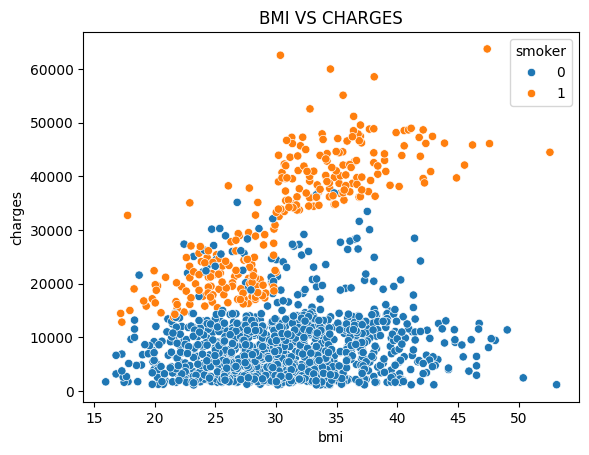

In [10]:
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker') # scatter plot to analyze impact of BMI on charges by smoking status
plt.title('BMI VS CHARGES') # title of the graph
plt.show() # Display the graph

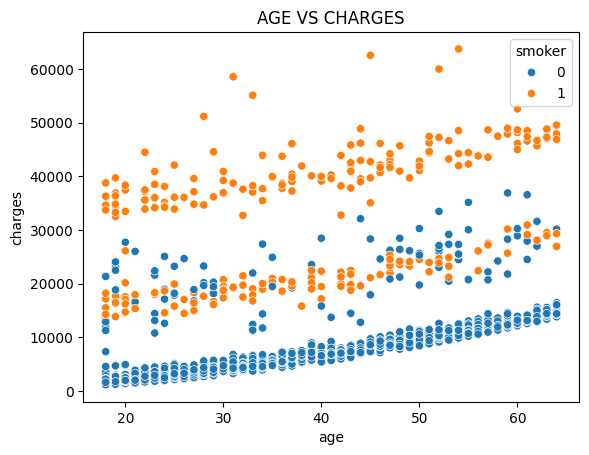

In [11]:
sns.scatterplot(data=df, x='age', y='charges', hue='smoker') # scatter plot to analyze impact of Age on charges by smoking status
plt.title('AGE VS CHARGES') # title of the graph
plt.show() # Display the graph

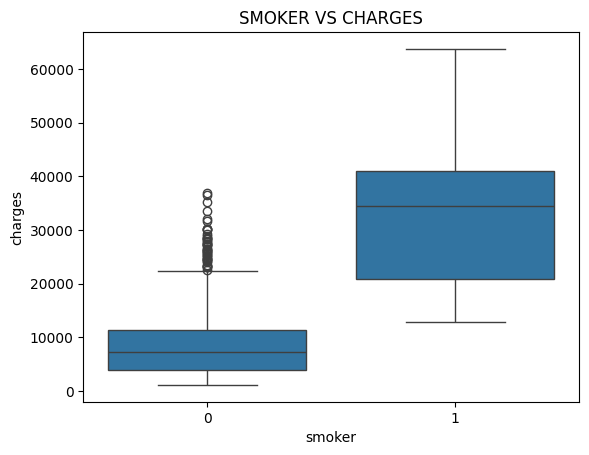

In [12]:
sns.boxplot(data=df, x='smoker', y='charges')             # boxplot to analyze impact of smokers on charges
plt.title('SMOKER VS CHARGES')                # title of the graph
plt.show()                                                       # displays the graph

In [15]:
X=df.drop('charges',axis=1)       # dropping columns not required for model training
y=df['charges']                   # target column to predict


In [16]:
from sklearn.model_selection import train_test_split  # importing train_test_split to split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)       # splitting data into 80% train and 20% test

In [17]:
from sklearn.linear_model import LinearRegression  # importing linear regression to predict charges
model = LinearRegression()  # creating linear regression model object

In [18]:
model.fit(X_train, y_train)   # training the model on training data

LinearRegression()

In [19]:
y_pred = model.predict(X_test)            # predicting loan status on test data

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error  # importing metrics to evaluate model performance
mae = mean_absolute_error(y_test, y_pred)  # calculating mean absolute error
print(mae)  # displaying MAE

4186.508898366433


In [21]:
df.describe()

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,1.515695,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,1.104885,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,4740.287150
50%,39.000000,1.000000,30.400000,1.000000,0.000000,2.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010


In [22]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5  # calculating root mean squared error
print(rmse)  # displaying RMSE

5799.587091438356


In [23]:
feat_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})  # creating dataframe of feature importance
print(feat_importance.sort_values('Coefficient', ascending=False))  # sorting by importance

    Feature   Coefficient
4    smoker  23647.818096
3  children    425.091456
2       bmi    335.781491
0       age    257.056264
1       sex    -18.791457
5    region   -271.284266
